# **Figure 4: Domain Length Distribution by DGA Family**

Imports

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd

Download Benign Domains

In [2]:
cisco_path = kagglehub.dataset_download("adebayo/cisco-umbrella-list")
cisco_path += "/top-1m.csv"
print(cisco_path)

C:\Users\Admin\.cache\kagglehub\datasets\adebayo\cisco-umbrella-list\versions\1/top-1m.csv


Download Malicious DGA Domains

In [3]:
dga_path = kagglehub.dataset_download("gtkcyber/dga-dataset")
dga_path += "/dga_data.csv"
print(dga_path)

C:\Users\Admin\.cache\kagglehub\datasets\gtkcyber\dga-dataset\versions\1/dga_data.csv


Load Datasets

In [4]:
benign_domains = pd.read_csv(cisco_path, header=None)
benign_domains.columns = ["rank", "domain"]
benign_domains["label"] = 0

dga_domains = pd.read_csv(dga_path)
dga_domains["label"] = dga_domains["subclass"].apply(lambda x: 0 if x in ["alexa", "legit"] else 1)
# remove fake DGAs
dga_domains = dga_domains[dga_domains["label"] == 1]

print("Length of Benign Domain dataset:", len(benign_domains))
print("Length of DGA Domain dataset:", len(dga_domains))

benign_sample = benign_domains[["domain", "label"]]
dga_sample = dga_domains[["domain", "label"]]
benign_sampler = benign_domains[["domain", "label"]].sample(n=len(dga_sample), random_state=60)
df_full = pd.concat([benign_sample, dga_sample], ignore_index=True)
df = pd.concat([benign_sampler, dga_sample], ignore_index=True)
# Drop any rows with missing domains
print("Missing domains (benign):", benign_sample["domain"].isna().sum())
print("Missing domains (DGA):   ", dga_sample["domain"].isna().sum())
df = df.dropna(subset=["domain"]).reset_index(drop=True)
df["domain"] = df["domain"].astype(str).str.lower()
df_full = df_full.dropna(subset=["domain"]).reset_index(drop=True)
df_full["domain"] = df_full["domain"].astype(str).str.lower()

print("\nClass balance:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

Length of Benign Domain dataset: 1000000
Length of DGA Domain dataset: 80000
Missing domains (benign): 0
Missing domains (DGA):    0

Class balance:
label
0    80000
1    80000
Name: count, dtype: int64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


Skipping bamital: not enough variation


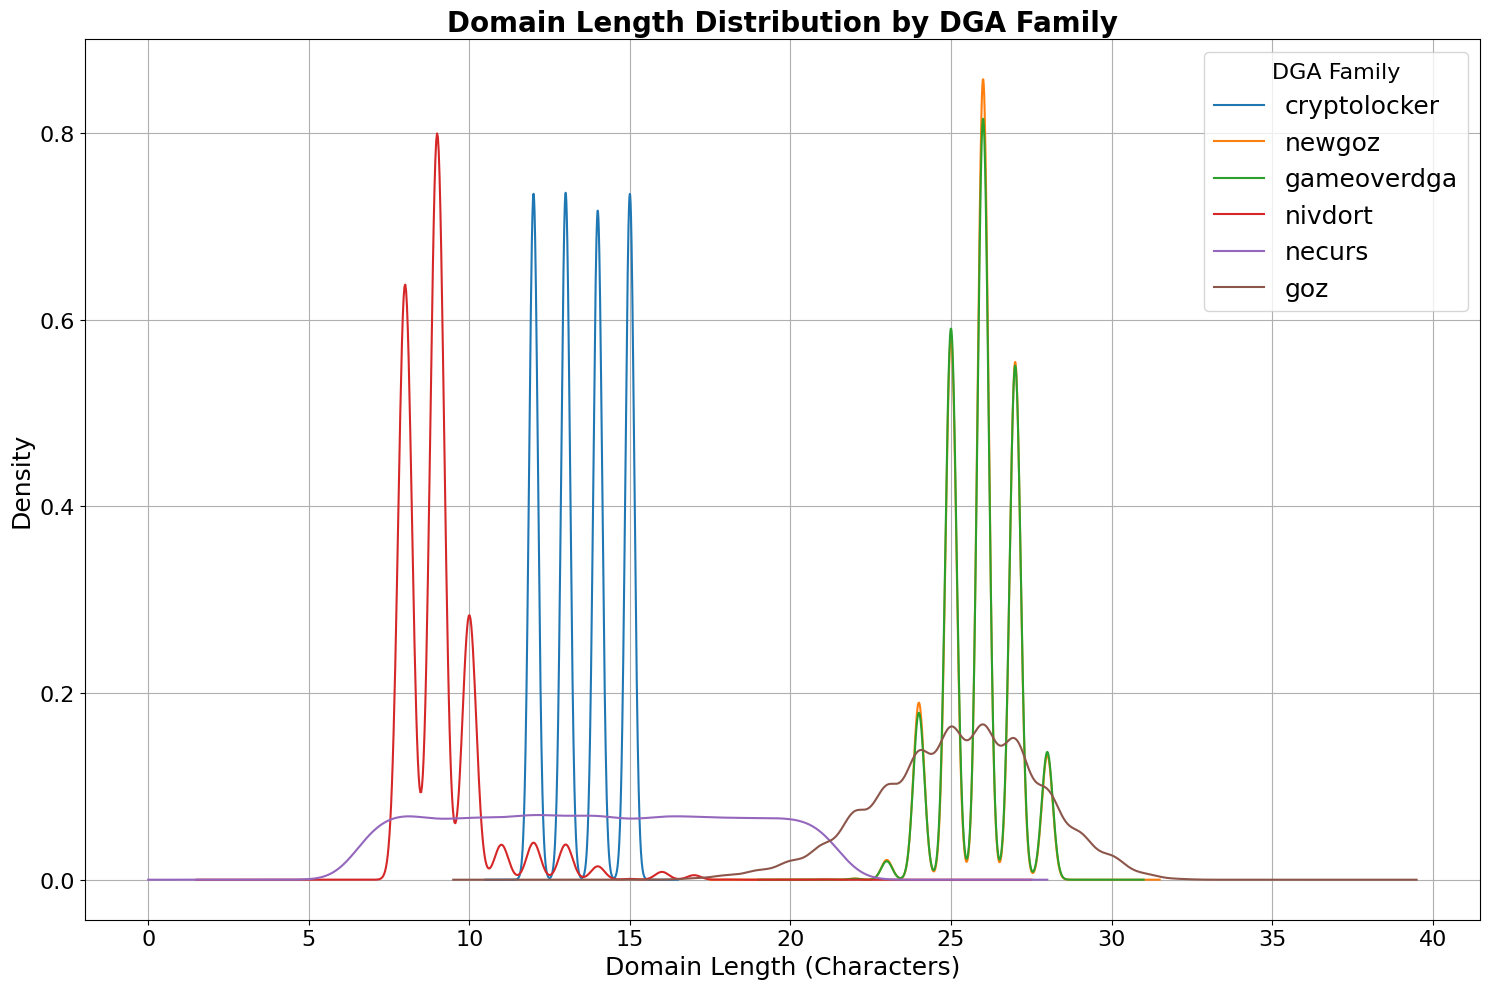

In [6]:
family_col = "subclass"

top_families = dga_domains[family_col].value_counts().head(10).index
dgas = dga_domains.copy()
dgas["length"] = dgas["domain"].str.split(".").str[0].str.len()

fig, ax = plt.subplots(figsize=(15, 10))
for family in top_families:
    subset = dgas[dgas[family_col] == family]["length"].dropna()
    if(subset.nunique() < 2):
        print(f"Skipping {family}: not enough variation")
        continue
    subset.plot(kind="kde", ax=ax, label=family)

ax.set_xlabel("Domain Length (Characters)", fontsize=18)
ax.set_ylabel("Density", fontsize=18)
ax.set_title("Domain Length Distribution by DGA Family", fontsize=20, fontweight="bold")
ax.tick_params(labelsize=16)
ax.legend(title="DGA Family", loc="upper right", fontsize=18, title_fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.savefig("../../figures/kde.pdf", format="pdf", bbox_inches="tight")
plt.show()